In [1]:
include("../src/cbdata.jl")
include("../src/ASVGeometry.jl")
include("../src/clarity.jl")

using .CBOFSData, .ASVGeometry, .Clarity
using Dates, Statistics, Plots, JuMP, Ipopt, Revise, ProgressMeter

In [2]:
function optimize_lap_speeds_full_spatiotemporal(weights, N, ds, P_in_W_avg, alpha_decay, vehicle_params, sigma_val)
    model = Model(Ipopt.Optimizer)
    set_silent(model)
    
    # NEW 1: Compute the true spatial integral of the weights
    W_int = sum(weights) * ds 
    
    # Precompute the sensing matrix S[j, k]
    S_matrix = zeros(N, N)
    path_length = N * ds
    for j in 1:N
        for k in 1:N
            dist_direct = abs((j-1)*ds - (k-1)*ds)
            dist_wrap = path_length - dist_direct
            shortest_dist = min(dist_direct, dist_wrap)
            S_matrix[j, k] = exp(-(shortest_dist^2) / (2 * sigma_val^2))
        end
    end
    
    safe_u_min = max(0.1, vehicle_params.u_min) 
    
    # NEW 2: Remove the rigid u_max limit to allow sprinting. 
    # (We keep a tiny 1e-4 lower bound just to prevent divide-by-zero errors in Ipopt)
    @variable(model, 1e-4 <= dt[1:N] <= ds/safe_u_min)
    
    @variable(model, 0 <= q[1:N, 1:N+1] <= 1.0)
    
    @variable(model, T_lap >= 0)
    @constraint(model, T_lap == sum(dt[k] for k in 1:N))
    
    # NEW 3: Scale the J_avg limits using the spatial integral
    @variable(model, 0 <= J_avg <= W_int)
    
    # NEW 4: Multiply by `ds` inside the sum to properly integrate across space
    @NLconstraint(model, 
        J_avg * T_lap == sum( weights[j] * 0.5 * (q[j, k] + q[j, k+1]) * dt[k] * ds for j in 1:N, k in 1:N )
    )
    @objective(model, Max, J_avg)
    
    @variable(model, E_avail >= 0)
    @constraint(model, E_avail == P_in_W_avg * T_lap)
    
    # Power Budget (Restored to the proper inequality per your toy problem)
    @NLconstraint(model, 
        sum(vehicle_params.kh * dt[k] + vehicle_params.km * (ds^3 / dt[k]^2) for k in 1:N) <= E_avail
    )
    
    for k in 1:N
        k_next = (k == N) ? 1 : k + 1 
        for j in 1:N
            S_k = S_matrix[j, k]
            S_k_next = S_matrix[j, k_next]
            @NLconstraint(model, 
                q[j, k+1] == q[j, k] + 0.5 * dt[k] * (
                    (S_k * (1 - q[j, k])^2 - alpha_decay * q[j, k]^2) + 
                    (S_k_next * (1 - q[j, k+1])^2 - alpha_decay * q[j, k+1]^2)
                )
            )
        end
    end
    
    @constraint(model, [j=1:N], q[j, 1] == q[j, N+1])
    
    u_nominal = 0.5 * (safe_u_min + vehicle_params.u_max)
    set_start_value.(dt, ds / u_nominal)
    set_start_value(T_lap, N * ds / u_nominal)
    set_start_value.(q, 0.5)
    
    # NEW 5: Warm start scaled by the spatial integral
    set_start_value(J_avg, 0.5 * W_int)
    set_start_value(E_avail, P_in_W_avg * (N * ds / u_nominal))
    
    optimize!(model)
    
    if termination_status(model) in [MOI.LOCALLY_SOLVED, MOI.OPTIMAL]
        return ds ./ value.(dt) 
    else
        println("Warning: Optimizer failed. Defaulting to nominal speed.")
        return fill(vehicle_params.u_max, N) 
    end
end

optimize_lap_speeds_full_spatiotemporal (generic function with 1 method)

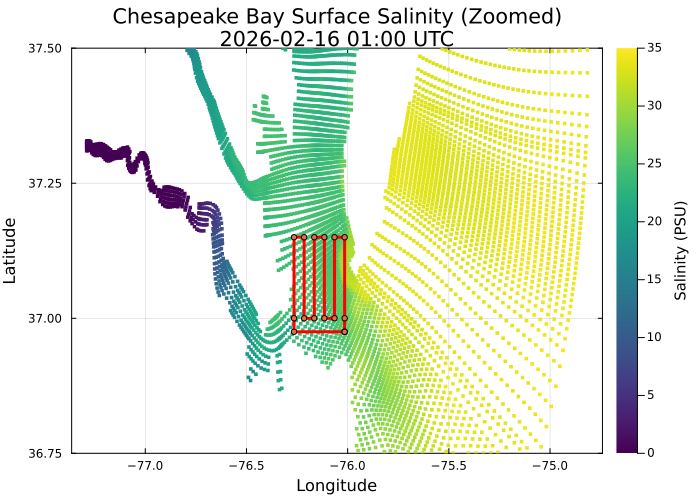

In [3]:
################### Transect Definition #######################################
# Start at the southeastern-most corner; southern return is offset by the same spacing (0.05°) as leg spacing
transect_lon = [
    -75.95, -75.95, -75.95,  # Start SE corner -> bottom of Leg 1 -> top of Leg 1
    -76.00, -76.00,          # Across top -> down Leg 2
    -76.05, -76.05,          # Across bottom -> up Leg 3
    -76.10, -76.10,          # Across top -> down Leg 4
    -76.15, -76.15,          # Across bottom -> up Leg 5
    -76.20, -76.20, -76.20,  # Across top -> down Leg 6 -> drop to southern return
    -75.95                   # Return east to close loop at start
]

t_lat_max = 37.05;
t_lat_min = 36.90;
t_lat_return = 36.875;  # Southern return line latitude

transect_lat = [
    t_lat_return, t_lat_min, t_lat_max,  # Start SE -> Leg 1 bottom -> Leg 1 top
    t_lat_max, t_lat_min,         # Leg 2 top -> Leg 2 bottom
    t_lat_min, t_lat_max,         # Leg 3 bottom -> Leg 3 top
    t_lat_max, t_lat_min,         # Leg 4 top -> Leg 4 bottom
    t_lat_min, t_lat_max,         # Leg 5 bottom -> Leg 5 top
    t_lat_max, t_lat_min, t_lat_return,  # Leg 6 top -> Leg 6 bottom -> southern return line
    t_lat_return                 # Close loop at SE start
]

# Shift path slightly west and north to avoid land overlap
lon_shift = -0.065   # west
lat_shift =  0.1  # north
transect_lon_shifted = transect_lon .+ lon_shift
transect_lat_shifted = transect_lat .+ lat_shift

lat_min, lat_max = 36.75, 37.5

### Load salinity data
frames = discover_files("./datafiles")

fr = frames[1]
lon_valid, lat_valid, salt_valid = load_surface_salinity(fr.file)
roi = (lat_valid .>= lat_min) .& (lat_valid .<= lat_max)

if any(roi)
    scatter(
        lon_valid[roi], lat_valid[roi],
        marker_z = salt_valid[roi],
        m = (1.8, :square, stroke(0)),
        c = :viridis,
        clims = (0, 35),
        colorbar = true,
        colorbar_title = "Salinity (PSU)",
        title = "Chesapeake Bay Surface Salinity (Zoomed)\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
        xlabel = "Longitude",
        ylabel = "Latitude",
        ylims = (lat_min, lat_max),
        legend = false,
        size = (700, 500),
        framestyle = :box,
        grid = true
    )

    plot!(
        transect_lon_shifted, transect_lat_shifted;
        lw = 3,
        lc = :red,
        marker = :circle,
        ms = 3,
        label = false
    )
else
    plot(
        transect_lon_shifted, transect_lat_shifted;
        title = "No ocean points in ROI\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
        xlabel = "Longitude",
        ylabel = "Latitude",
        ylims = (lat_min, lat_max),
        lw = 3,
        lc = :red,
        marker = :circle,
        ms = 3,
        legend = false,
        label = false
    )
end


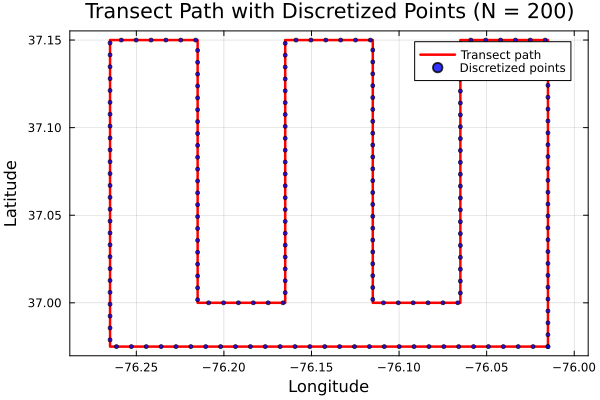

In [4]:
# Initialize ASV geometry and simulate path discretization
u_nominal = 1.75  # m/s
vehicle_params = VehicleParams(u_nominal, 24*3600.0)  # 24 hours at 1.75 m/s nominal speed

npts = 200
lon_path, lat_path, s_vec = discretize_polyline(transect_lon_shifted, transect_lat_shifted, npts)
path_length_m = s_vec[end]

plot(
    transect_lon_shifted, transect_lat_shifted;
    lw = 2.5,
    lc = :red,
    label = "Transect path",
    xlabel = "Longitude",
    ylabel = "Latitude",
    title = "Transect Path with Discretized Points (N = $npts)",
    legend = :topright,
    aspect_ratio = :equal,
    framestyle = :box,
    grid = true
)

scatter!(
    lon_path, lat_path;
    ms = 2.2,
    mc = :blue,
    alpha = 0.8,
    label = "Discretized points"
)

In [6]:
# Simulation parameters
dt_step_sec = 60.0              # 1 minute per step
sigma_val = 3000.0              # Sensing footprint [m]
alpha_val = 0.05                # Clarity decay

# NEW: Calculate Power Budget based on nominal baseline speed
power_nominal = vehicle_params.kh + vehicle_params.km * (u_nominal^3)
P_in_W = power_nominal          # Continuous Solar Power Generation [Watts]
# P_in_W = 750.0

# Path Discretization for JuMP
N_segments = npts - 1               # Number of path segments
ds = path_length_m / N_segments     # Length of each segment [m]

# Generate times (assuming frames are 1 hour apart, step every minute)
sim_times = collect(frames[1].dt : Minute(1) : frames[end].dt)
N_steps = length(sim_times)
current_weights = fill(1.0, npts)


200-element Vector{Float64}:
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 ⋮
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0

In [ ]:


# Run optimizer
u_opt_segments_full = optimize_lap_speeds_full_spatiotemporal(current_weights, N_segments, ds, P_in_W, alpha_val, vehicle_params, sigma_val)
plot(u_opt_segments_full, ylims=(0, vehicle_params.u_max * 1.2), xlabel="Segment Index", ylabel="Optimized Speed (m/s)", title="Optimized Segment Speeds (Full Spatiotemporal Model)", legend=false)

In [7]:
# Variable spatial weights and free final time bounded by the simulation duration

function optimize_variable_weights(weights, N, ds, P_in_W_avg,
                                   alpha_decay, vehicle_params,
                                   sigma_val, T_max)

    model = Model(Ipopt.Optimizer)
    set_silent(model)

    weights = collect(weights[1:N])
    W_int = sum(weights) * ds
    path_length = N * ds

    S_matrix = zeros(N, N)
    for j in 1:N, k in 1:N
        d = abs((j - 1) * ds - (k - 1) * ds)
        d = min(d, path_length - d)
        S_matrix[j, k] = exp(-(d^2) / (2 * sigma_val^2))
    end

    # No minimum-speed constraint: dt is only required to be positive and
    # consistent with the total-time bound T_max.
    @variable(model, 1e-4 <= dt[1:N] <= T_max)
    @variable(model, 0 <= q[1:N, 1:N+1] <= 1)
    @variable(model, 0 <= T_lap <= T_max)
    @variable(model, 0 <= J_avg <= W_int)

    @constraint(model, T_lap == sum(dt))
    @NLconstraint(model,
        J_avg * T_lap ==
        sum(weights[j] * 0.5 * (q[j, k] + q[j, k + 1]) *
            dt[k] * ds for j in 1:N, k in 1:N)
    )

    @variable(model, E_avail >= 0)
    @constraint(model, E_avail == P_in_W_avg * T_lap)

    @NLconstraint(model,
        sum(vehicle_params.kh * dt[k] +
            vehicle_params.km * ds^3 / dt[k]^2 for k in 1:N) <= E_avail
    )

    for k in 1:N
        k_next = k == N ? 1 : k + 1
        for j in 1:N
            @NLconstraint(model,
                q[j, k + 1] == q[j, k] + 0.5 * dt[k] *
                ((S_matrix[j, k] * (1 - q[j, k])^2 -
                  alpha_decay * q[j, k]^2) +
                 (S_matrix[j, k_next] * (1 - q[j, k + 1])^2 -
                  alpha_decay * q[j, k + 1]^2))
            )
        end
    end

    @constraint(model, [j = 1:N], q[j, 1] == q[j, N + 1])

    # Use a nominal initialization without a minimum-speed floor.
    u0 = 0.5 * vehicle_params.u_max
    set_start_value.(dt, ds / u0)
    set_start_value.(q, 0.5)
    set_start_value(T_lap, min(N * ds / u0, T_max))
    set_start_value(J_avg, 0.5 * W_int)

    @objective(model, Max, J_avg)
    optimize!(model)

    if termination_status(model) in [MOI.LOCALLY_SOLVED, MOI.OPTIMAL]
        return ds ./ value.(dt), value(T_lap), value(J_avg)
    else
        @warn "Optimizer failed; using nominal speed."
        return fill(u0, N), NaN, NaN
    end
end


optimize_variable_weights (generic function with 1 method)

Optimized lap time: 23.837123362207137 hours
Optimized average clarity: 13396.490562712297


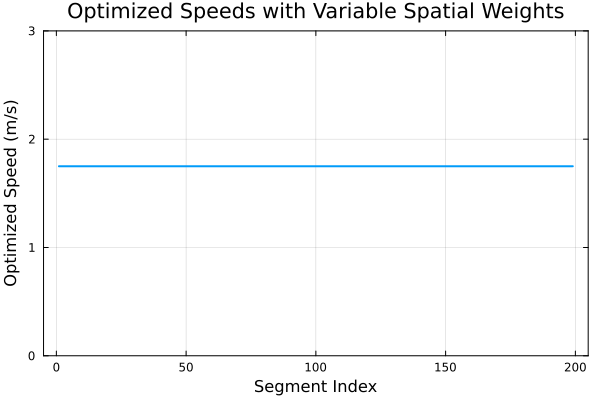

In [8]:
# Maximum allowed simulation duration [s]
T_max = Dates.value(sim_times[end] - sim_times[1]) / 1000

u_opt_variable, T_lap_opt, J_avg_opt = optimize_variable_weights(
    current_weights,
    N_segments,
    ds,
    P_in_W,
    alpha_val,
    vehicle_params,
    sigma_val,
    T_max
)

println("Optimized lap time: $(T_lap_opt / 3600) hours")
println("Optimized average clarity: $J_avg_opt")

plot(
    u_opt_variable;
    xlabel = "Segment Index",
    ylabel = "Optimized Speed (m/s)",
    title = "Optimized Speeds with Variable Spatial Weights",
    ylims = (0, vehicle_params.u_max * 1.2),
    legend = false,
    lw = 2,
    framestyle = :box
)

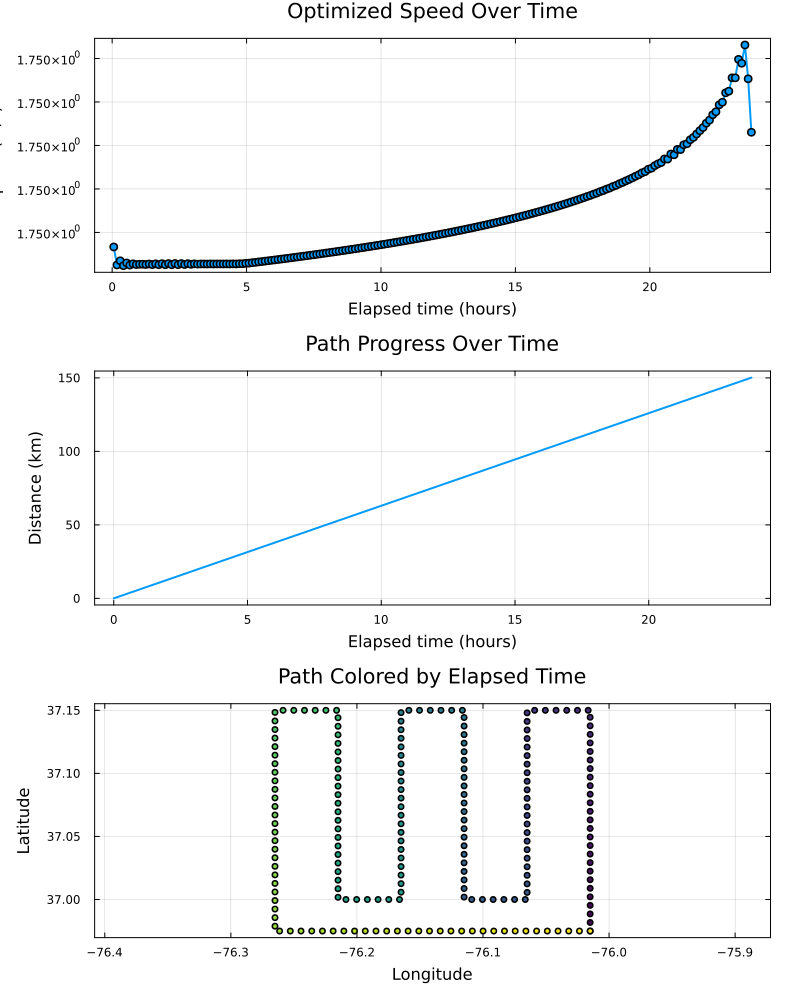

In [10]:
# Time associated with each discretized segment
dt_opt = ds ./ u_opt_variable
t_sec = [0.0; cumsum(dt_opt)]
t_hours = t_sec ./ 3600

# Segment midpoint times for the speed profile
t_mid_hours = 0.5 .* (t_hours[1:end-1] .+ t_hours[2:end])

p_speed = plot(
    t_mid_hours,
    u_opt_variable;
    xlabel = "Elapsed time (hours)",
    ylabel = "Speed (m/s)",
    title = "Optimized Speed Over Time",
    lw = 2,
    marker = :circle,
    legend = false,
    framestyle = :box
)

p_distance = plot(
    t_hours,
    [0.0; cumsum(fill(ds, N_segments))] ./ 1000;
    xlabel = "Elapsed time (hours)",
    ylabel = "Distance (km)",
    title = "Path Progress Over Time",
    lw = 2,
    legend = false,
    framestyle = :box
)

p_path = scatter(
    lon_path,
    lat_path;
    marker_z = t_hours,
    c = :viridis,
    marker = :circle,
    ms = 3,
    xlabel = "Longitude",
    ylabel = "Latitude",
    title = "Path Colored by Elapsed Time",
    colorbar_title = "Time (hours)",
    aspect_ratio = :equal,
    legend = false,
    framestyle = :box
)

plot(p_speed, p_distance, p_path; layout = (3, 1), size = (800, 1000))

In [8]:
# Maximum allowed simulation duration [s]
T_max = Dates.value(sim_times[end] - sim_times[1]) / 1000

x = range(0, 1; length = npts)

varied_weights = 1 .+
    5 .* exp.(-((x .- 0.30) ./ 0.06).^2) .+
    5 .* exp.(-((x .- 0.80) ./ 0.06).^2)


u_opt_variable, T_lap_opt, J_avg_opt = optimize_variable_weights(
    varied_weights,
    N_segments,
    ds,
    P_in_W,
    alpha_val,
    vehicle_params,
    sigma_val,
    T_max
)

println("Optimized lap time: $(T_lap_opt / 3600) hours")
println("Optimized average clarity: $J_avg_opt")



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Optimized lap time: 119.00000002770881 hours
Optimized average clarity: 59389.69234458382


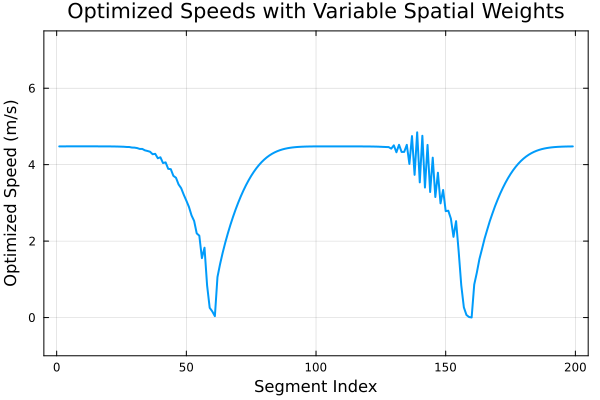

In [14]:

plot(
    u_opt_variable;
    xlabel = "Segment Index",
    ylabel = "Optimized Speed (m/s)",
    title = "Optimized Speeds with Variable Spatial Weights",
    ylims = (-1.0, vehicle_params.u_max * 3),
    legend = false,
    lw = 2,
    framestyle = :box
)

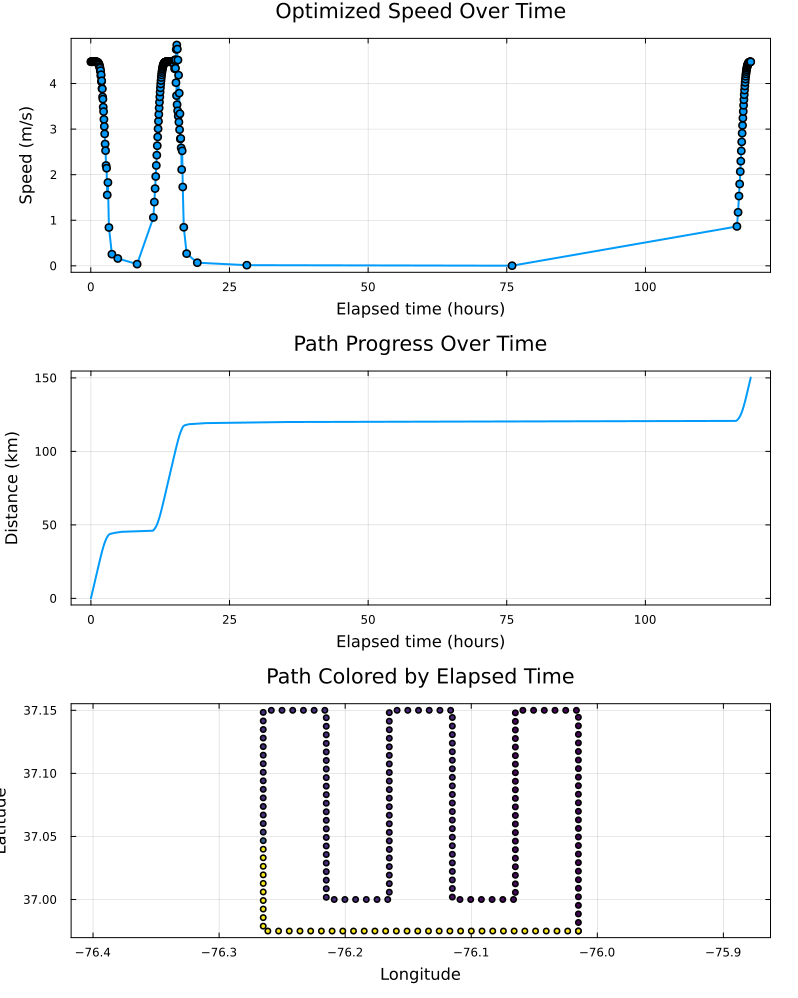

In [10]:
# Time associated with each discretized segment
dt_opt = ds ./ u_opt_variable
t_sec = [0.0; cumsum(dt_opt)]
t_hours = t_sec ./ 3600

# Segment midpoint times for the speed profile
t_mid_hours = 0.5 .* (t_hours[1:end-1] .+ t_hours[2:end])

p_speed = plot(
    t_mid_hours,
    u_opt_variable;
    xlabel = "Elapsed time (hours)",
    ylabel = "Speed (m/s)",
    title = "Optimized Speed Over Time",
    lw = 2,
    marker = :circle,
    legend = false,
    framestyle = :box
)

p_distance = plot(
    t_hours,
    [0.0; cumsum(fill(ds, N_segments))] ./ 1000;
    xlabel = "Elapsed time (hours)",
    ylabel = "Distance (km)",
    title = "Path Progress Over Time",
    lw = 2,
    legend = false,
    framestyle = :box
)

p_path = scatter(
    lon_path,
    lat_path;
    marker_z = t_hours,
    c = :viridis,
    marker = :circle,
    ms = 3,
    xlabel = "Longitude",
    ylabel = "Latitude",
    title = "Path Colored by Elapsed Time",
    colorbar_title = "Time (hours)",
    aspect_ratio = :equal,
    legend = false,
    framestyle = :box
)

plot(p_speed, p_distance, p_path; layout = (3, 1), size = (800, 1000))

In [11]:
# Energy expended by the vehicle and energy supplied during the optimized lap
energy_expended_J = sum(
    vehicle_params.kh .* dt_opt .+
    vehicle_params.km .* (ds^3 ./ dt_opt.^2)
)

energy_in_J = P_in_W * T_lap_opt

println("Energy expended: $(energy_expended_J) J ($(energy_expended_J / 3.6e6) kWh)")
println("Energy in:       $(energy_in_J) J ($(energy_in_J / 3.6e6) kWh)")
println("Energy balance:  $(energy_in_J - energy_expended_J) J")

Energy expended: 1.9484836879504317e8 J (54.12454688751199 kWh)
Energy in:       1.9484836879536986e8 J (54.12454688760274 kWh)
Energy balance:  0.000326693058013916 J


In [13]:
minimum(u_opt_variable)

0.0025931116609697945

# Target weighting parameter sensitvity